../output_results/E_pos/main\upos_2026-05-02_17-32-33_e-50_s-20_spatial.pt
Evaluation | samples=29103 | loss=0.6572 | acc=0.8535 | eval_time_ms=40353.24
Average AC operations per sample: 171324.41
Average energy per sample: 4391044.59 pJ
40353.23789995164


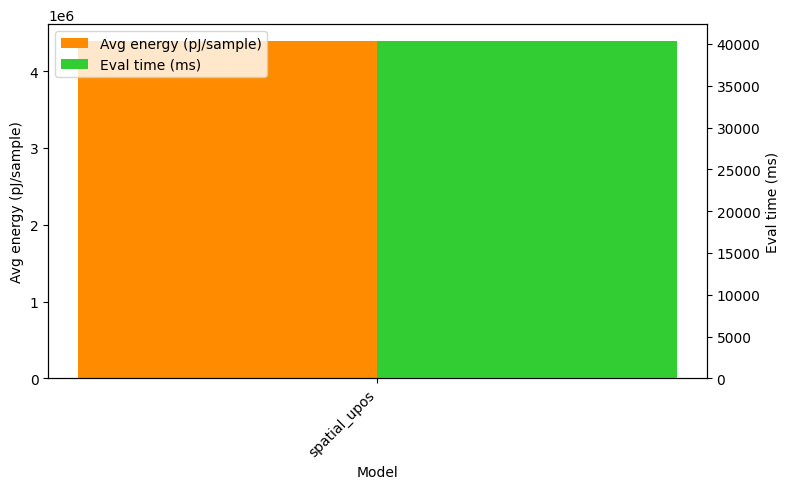

In [ ]:
from E_pos_eval import evaluate_model
from glob import glob
from pathlib import Path
import json
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
from colors import colors

models = sorted(glob('../output_results/E_pos/main/*.pt'))

labels = []
avg_energy_pj_per_sample = []
eval_time_ms = []

for model_path in models:
    meta_path = Path(model_path).with_suffix('.json')
    # print(model_path, meta_path)
    meta = json.loads(meta_path.read_text()).get('training_config', {})
    args = Namespace(**(meta | {
        "model_path": model_path,
        "diagnose": False,
        # "diagnose": True,
        # "limit": 10,
        "limit": None,
        "split": "test",
        # "estimate_energy": False,
        "estimate_energy": True,
        "energy_ac_cost_pj": 25.63,
        "output_json": None,
    }))
    # Try to cast each number-like argument to int if possible, since JSON doesn't distinguish.
    args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
    results = evaluate_model(args)
    labels.append('_'.join([meta.get('input_mode'), meta.get('output_file_prefix') or 'poisson_sc']))
    avg_energy_pj_per_sample.append(results['avg_energy_pj_per_sample'])
    eval_time_ms.append(results.get('eval_time_ms', 0))
    # print(results['eval_time_ms'])

positions = np.arange(len(labels))
width = 0.38

fig, ax1 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
ax2 = ax1.twinx()

bars_energy = ax1.bar(positions - width/2, avg_energy_pj_per_sample, width, color=colors.energy, label='Avg energy (pJ/sample)')
bars_time = ax2.bar(positions + width/2, eval_time_ms, width, color=colors.time, label='Eval time (ms)')

ax1.set_xlabel('Model')
ax1.set_ylabel('Avg energy (pJ/sample)')
ax2.set_ylabel('Eval time (ms)')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()